In [53]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.gridspec import GridSpec
import typing as t

max_robots = 10
algs = {
    "namo": "C-NAMO",
    "namo_ndr": "C-NAMO no DR",
    "namo_ncr": "C-NAMO no CR",
    "snamo": "S-NAMO",
    "snamo_ndr": "S-NAMO no DR",
    "snamo_ncr": "S-NAMO no CR",
}

scenario = 'willow_garage_multi_shape'
data = pandas.read_csv(f"../report_{scenario}.csv")
data["succeeded"] = data["succeeded"].astype(int)
data_successes = data[data["succeeded"] == 1]
sum_goals_per_agent_per_sim = data.groupby(['n_robots', 'algorithm', 'sim_id', 'agent_id']).sum().reset_index()
avg_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).mean()
std_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).std()
count_per_agent = sum_goals_per_agent_per_sim.drop(columns=["agent_id", "sim_id"]).groupby(['n_robots', 'algorithm']).count()

data = data.drop(columns=["agent_id", "sim_id"])
success_rates = data.groupby(['n_robots','algorithm'])['succeeded'].mean().reset_index()


In [54]:
avg_per_agent

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo       48.750000       44012.616777    29.650000     201.687598   
         namo_ncr   48.750000       44012.616777    29.650000     202.751007   
         namo_ndr   48.750000       44012.616777    29.650000     202.781945   
         snamo      48.500000       49611.401167    18.850000     348.275065   
         snamo_ncr  48.550000       49987.477872    18.950000     348.600745   
         snamo_ndr  48.500000       49478.216841    18.950000     350.576587   
2        namo       46.825000       72462.263909    21.475000     288.659680   
         namo_ncr   24.375000       22800.562800    13.375000     176.177114   
         namo_ndr   43.150000       53054.150915    20.775000     262.707663   
         snamo      44.625000       48605.910501    13.600000     498.417518   
         snamo_ncr  26.175000       26192.340116     9.625000     404.404350   
         snamo_ndr  39.175000       40657.456290    12.525000     494.936598   
3        namo       45.683333       83975.111699    18.833333     375.468984   
         namo_ncr   17.150000       16737.147475     8.850000     180.803534   
         namo_ndr   36.700000       55083.606262    16.033333     325.956979   
         snamo      41.300000       53979.527592    11.683333     655.893556   
         snamo_ncr  17.233333       17035.867525     6.366667     521.135132   
         snamo_ndr  35.216667       42121.578536    10.400000     628.834899   
4        namo       44.037500       97876.464530    16.900000     509.848823   
         namo_ncr   13.925000       15693.815217     6.962500     186.983985   
         namo_ndr   29.712500       49155.130347    12.337500     388.166121   
         snamo      39.400000       59069.360918     9.787500     734.073806   
         snamo_ncr  14.387500       13003.661094     4.812500     563.636614   
         snamo_ndr  29.037500       42595.570725     8.150000     704.610876   
5        namo       40.750000      100770.504658    15.430000     625.463043   
         namo_ncr   10.410000       10333.364603     4.960000     167.135463   
         namo_ndr   22.110000       41394.158223     9.850000     410.327388   
         snamo      36.580000       61100.108621     8.310000     784.838548   
         snamo_ncr  10.400000        9243.409978     3.790000     648.781072   
         snamo_ndr  22.000000       32729.681955     6.030000     779.182706   
6        namo       35.291667       93956.778197    13.308333     708.650364   
         namo_ncr    8.616667        8060.705712     3.900000     164.903267   
         namo_ndr   19.883333       39062.862897     7.841667     428.227737   
         snamo      33.691667       62526.848599     7.550000     907.240524   
         snamo_ncr   8.650000        7978.191704     2.766667     670.597441   
         snamo_ndr  18.308333       29211.803556     5.183333     863.083352   
7        namo       29.600000       85646.159904    10.971429     799.809374   
         namo_ncr    7.792857        7356.269593     3.800000     198.469565   
         namo_ndr   15.442857       30420.774415     6.557143     449.295090   
         snamo      26.464286       54954.607387     6.328571    1039.545484   
         snamo_ncr   6.935714        6601.341923     2.342857     776.591735   
         snamo_ndr  15.357143       25075.157140     4.450000     974.336434   
8        namo       28.200000       86436.646078    10.375000     878.510360   
         namo_ncr    5.931250        5423.955806     2.893750     187.869588   
         namo_ndr   13.406250       26439.095798     5.637500     458.848883   
         snamo      26.531250       58042.837818     5.962500    1048.673788   
         snamo_ncr   6.293750        5538.916132     2.162500     730.134265   
         snamo_ndr  12.281250       21558.439242     3.631250     957.992380   
9        namo       

In [55]:
std_per_agent

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        1.409554        8393.433477     5.751659      52.164442   
         namo_ncr    1.409554        8393.433477     5.751659      56.843838   
         namo_ndr    1.409554        8393.433477     5.751659      55.849773   
         snamo       1.605910       10951.327509     2.007224      48.131215   
         snamo_ncr   1.605091       11133.871445     1.848897      47.766084   
         snamo_ndr   1.605910       11019.117313     2.235479      50.068347   
2        namo        2.872393       26416.472397     4.668429      71.491672   
         namo_ncr   10.344545       11902.326884     6.007207      50.942619   
         namo_ndr    4.029061       11094.135564     4.875304      70.328178   
         snamo       3.766843        7389.541257     3.326660     243.070022   
         snamo_ncr   7.662387        8059.067201     2.647568     189.725026   
         snamo_ndr   9.718836       11777.774502     3.809485     268.324955   
3        namo        4.813440       29613.174787     4.231307     101.804461   
         namo_ncr    8.817980        9330.278512     5.945587      94.691293   
         namo_ndr    6.167987       13644.457155     3.974353      82.427540   
         snamo       5.172614       10151.494308     2.994298     282.767234   
         snamo_ncr  10.522561       12028.527021     3.541362     330.845509   
         snamo_ndr   6.257448        8464.924624     2.817620     361.910322   
4        namo        4.240981       38110.733257     5.522337     131.324307   
         namo_ncr    9.352147       11061.542040     5.132285      61.608168   
         namo_ndr    6.997637       15160.657175     4.251415     144.716177   
         snamo       6.719705       15133.300455     2.945470     370.739767   
         snamo_ncr   8.891033        8320.056532     2.859998     409.123404   
         snamo_ndr   6.355390       13991.688372     2.700680     389.061675   
5        namo        5.364257       35176.865776     4.876774     144.161261   
         namo_ncr    6.931257        7651.144209     3.676076      70.372202   
         namo_ndr    8.095260       15762.673823     4.971383     127.511953   
         snamo       7.293528       19603.846732     3.212020     417.339876   
         snamo_ncr   8.407548        7561.123252     3.188664     485.255508   
         snamo_ndr   9.033048       19208.828312     3.108980     477.896670   
6        namo        6.745550       35177.107377     4.806851     162.711590   
         namo_ncr    6.614452        6387.241004     3.013694      62.880713   
         namo_ndr    5.868565       15067.197300     3.305193     115.008719   
         snamo       7.801956       23130.780337     3.042693     502.023986   
         snamo_ncr   6.091253        6243.607300     2.109336     556.587595   
         snamo_ndr   7.755503       13313.330950     2.540374     528.912749   
7        namo        7.440701       36396.257114     4.324837     168.869284   
         namo_ncr    6.703909        7123.347565     3.911246      86.125345   
         namo_ndr    5.647017       13572.370467     3.318298     130.637155   
         snamo       9.443060       24842.031915     2.968523     635.811951   
         snamo_ncr   7.014077        8517.613190     2.194733     544.438692   
         snamo_ndr   7.833769       17274.567901     2.423877     665.210347   
8        namo        6.976871       35930.893036     3.998034     168.434131   
         namo_ncr    5.469322        4968.366631     2.893491      70.414007   
         namo_ndr    6.370428       15690.578906     3.490306     145.845830   
         snamo       9.611917       26958.002830     2.872309     585.671867   
         snamo_ncr   6.282247        5936.206722     2.245576     538.925459   
         snamo_ndr   5.775868       11391.149762     2.123904     650.478516   
9        namo       

In [56]:
success_rates

,n_robots,algorithm,succeeded
0,1,namo,0.975000
1,1,namo_ncr,0.975000
2,1,namo_ndr,0.975000
3,1,snamo,0.970000
4,1,snamo_ncr,0.971000
5,1,snamo_ndr,0.970000
6,2,namo,0.936500
7,2,namo_ncr,0.487500
8,2,namo_ndr,0.863000
9,2,snamo,0.892500


In [57]:
def plot_metric_by_num_robots(
    *,
    ax: Axes,
    algs: t.Dict[str, str],
    max_robots: int,
    avg,
    std,
    ylabel: str,
    show_legend: bool = False,
    show_std: bool = False
):
    fig_legend = plt.figure("Legend")

    lines = []
    labels = []
    for alg, title in algs.items():
        means = np.array([avg.loc[(i, alg)] for i in range(1, max_robots + 1)])
        stds = np.array([std.loc[(i, alg)] for i in range(1, max_robots + 1)])
        (line,) = ax.plot(
            range(1, max_robots + 1),
            means,
            label=title,
        )
        lines.append(line)
        labels.append(title)
        if show_std:
            ax.fill_between(
                x=range(1, max_robots + 1),
                y1=means - stds,
                y2=means + stds,
                alpha=0.2,
            )
    fig_legend.legend(lines, labels, loc='center', frameon=False)
    fig_legend.savefig(f'{scenario}_legend.png', bbox_inches='tight')
    # ax.set_ylabel(ylabel)
    ax.set_xlim([1, max_robots])

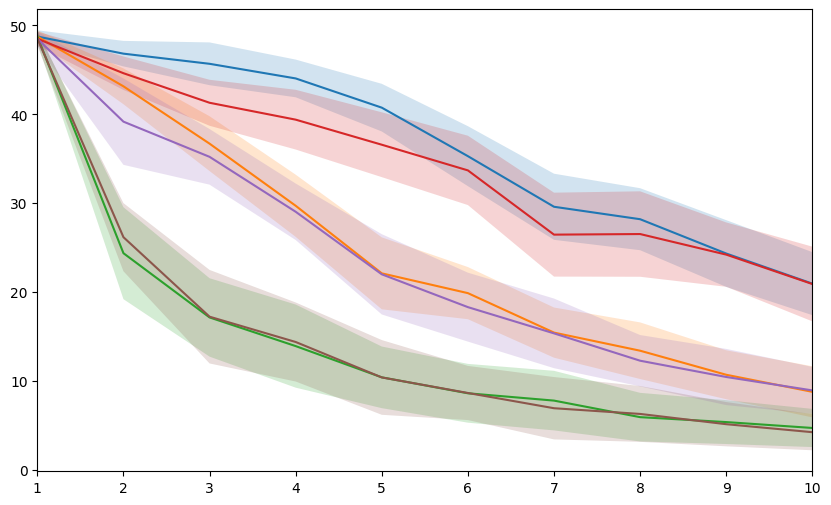

<Figure size 640x480 with 0 Axes>

In [58]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['succeeded'],
    std=std_per_agent['succeeded'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Goal Success Rate",
    show_std=True
)
fig.savefig(f'{scenario}_success_rates.png', bbox_inches='tight')

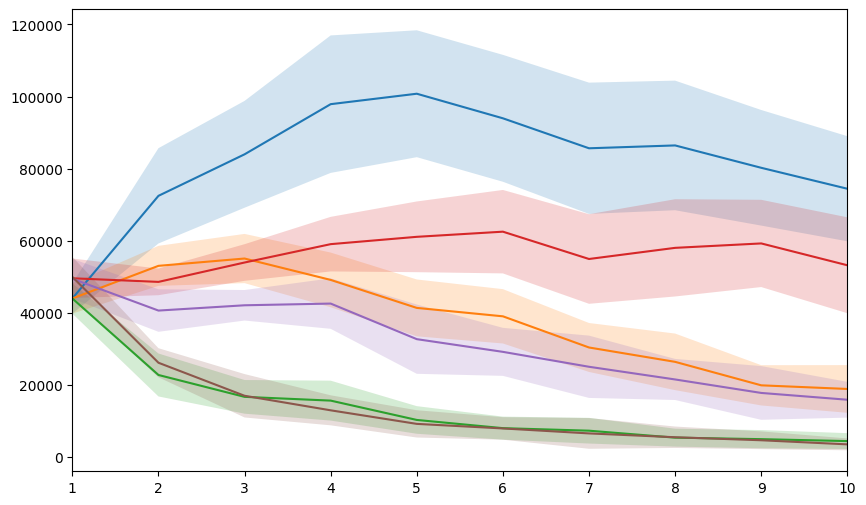

<Figure size 640x480 with 0 Axes>

In [59]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['distance_traveled'],
    std=std_per_agent['distance_traveled'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Distance",
    show_std=True
)
fig.savefig(f'{scenario}_distance.png', bbox_inches='tight')

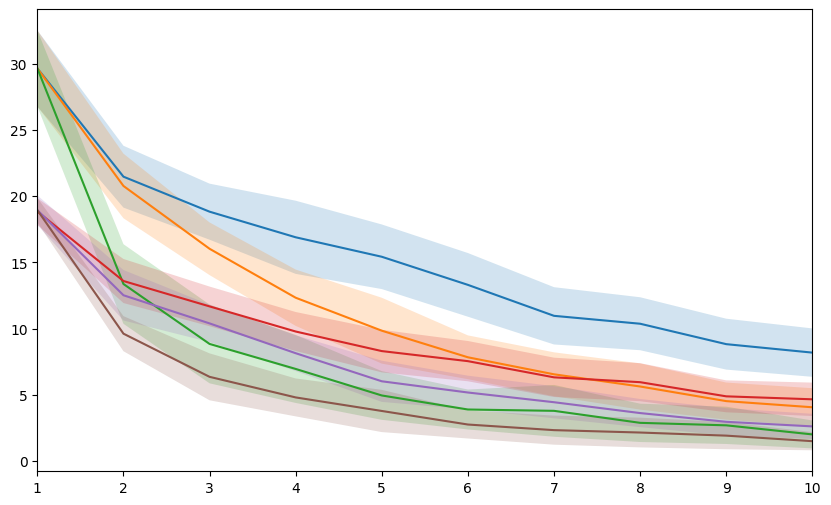

<Figure size 640x480 with 0 Axes>

In [60]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_transfers'],
    std=std_per_agent['n_transfers'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Transfers",
    show_std=True
)
fig.savefig(f'{scenario}_transfers.png', bbox_inches='tight')

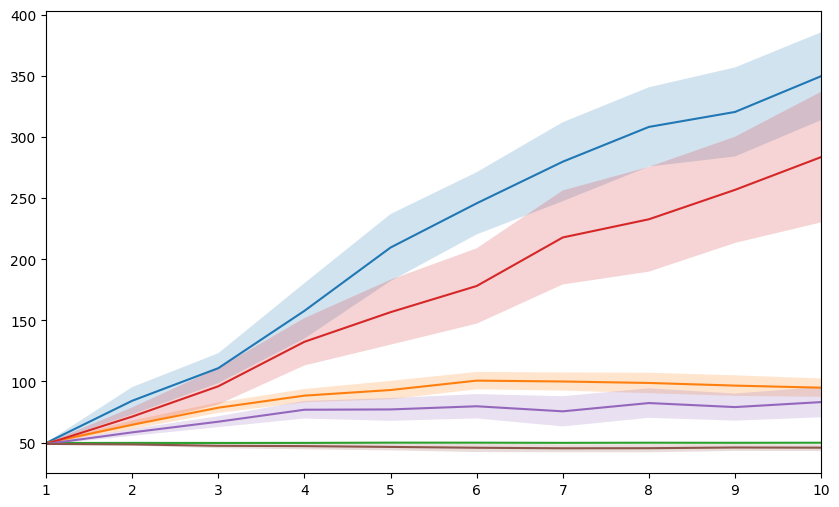

<Figure size 640x480 with 0 Axes>

In [61]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['replans'],
    std=std_per_agent['replans'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Replans",
    show_std=True
)
fig.savefig(f'{scenario}_replans.png', bbox_inches='tight')

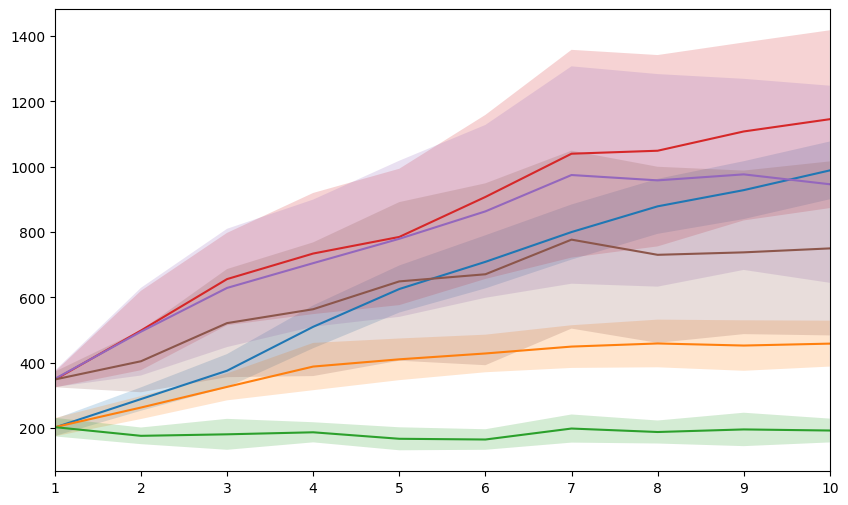

<Figure size 640x480 with 0 Axes>

In [62]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['planning_time'],
    std=std_per_agent['planning_time'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
    show_std=True
)
fig.savefig(f'{scenario}_planning_time.png', bbox_inches='tight')

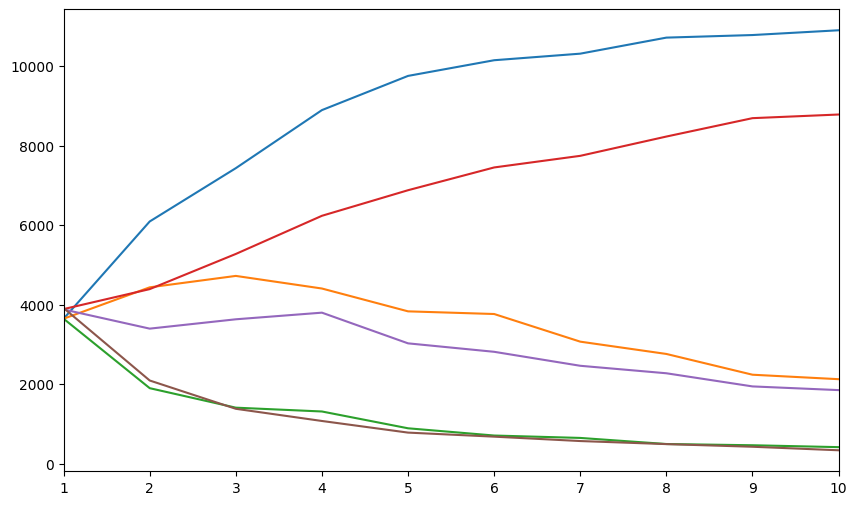

<Figure size 640x480 with 0 Axes>

In [63]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_steps'],
    std=std_per_agent['n_steps'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Steps",
    show_std=False
)
fig.savefig(f'{scenario}_steps.png', bbox_inches='tight')

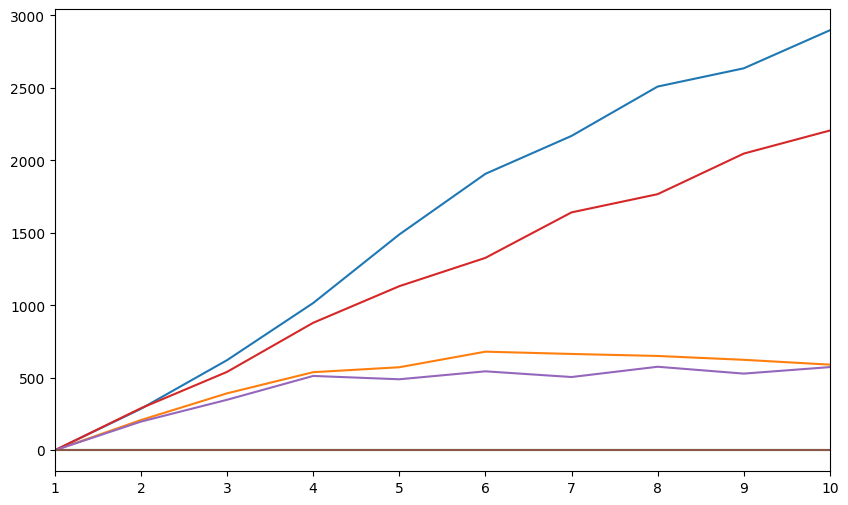

<Figure size 640x480 with 0 Axes>

In [64]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['postponements'],
    std=std_per_agent['postponements'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Postponments",
    show_std=False
)
fig.savefig(f'{scenario}_postpones.png', bbox_inches='tight')

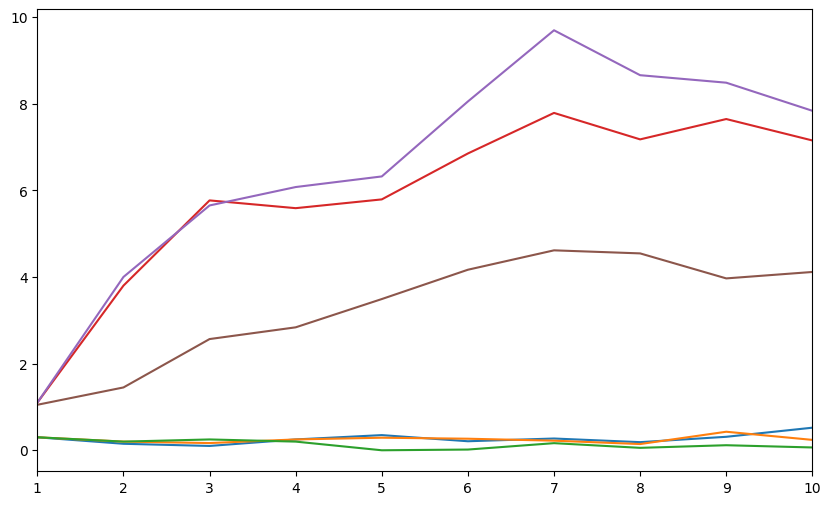

<Figure size 640x480 with 0 Axes>

In [65]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_agent['n_planning_timeouts'],
    std=std_per_agent['n_planning_timeouts'] / 2,
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Timeouts",
    show_std=False
)
fig.savefig(f'{scenario}_timeouts.png', bbox_inches='tight')